In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from gam_rs_utils.utils import *

def plot_two_var(results, x, y):
    fig, ax = plt.subplots()
    for dataset_name, data_group in results.groupby("dataset"):
        xs = data_group[x]
        ys = data_group[y]
        ax.plot(xs, ys, label=dataset_name, marker="o")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend()
    plt.show()

### Comparing Order Bias

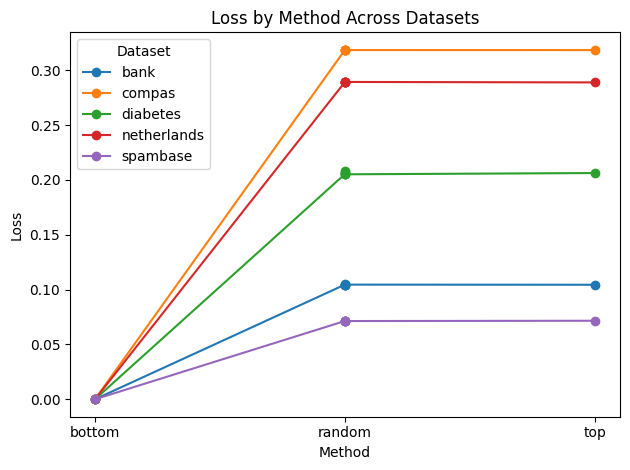

In [ ]:
with open("results/order.pkl", "rb") as f:
    results = pickle.load(f)

results = pd.DataFrame(results)

x_order = ["bottom", "random", "top"]
fig, ax = plt.subplots()
for dataset_name, values in results.groupby("dataset"):
    sorted_vals = values.sort_values(by="feature_selection")
    xs = sorted_vals["feature_selection"]
    ys = sorted_vals["loss"]
    ax.plot(xs, ys, marker='o', label=dataset_name)

# Format x-axis
ax.set_xticks(range(3))
ax.set_xticklabels(x_order)
ax.set_xlabel("Method")
ax.set_ylabel("Loss")
ax.legend(title="Dataset")
ax.set_title("Loss by Method Across Datasets")

plt.tight_layout()
plt.show()

### Number of Features

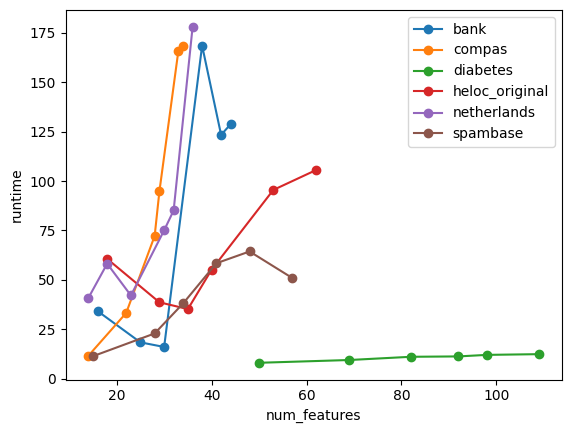

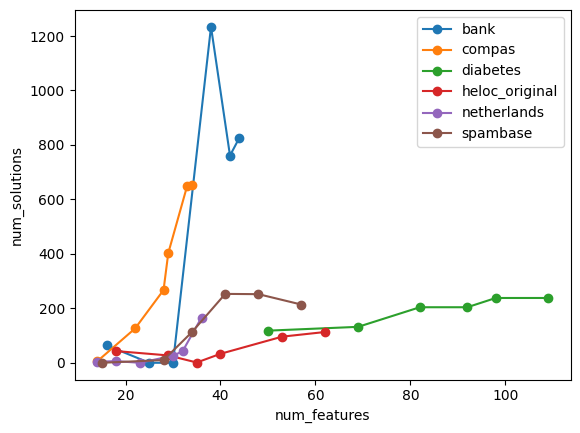

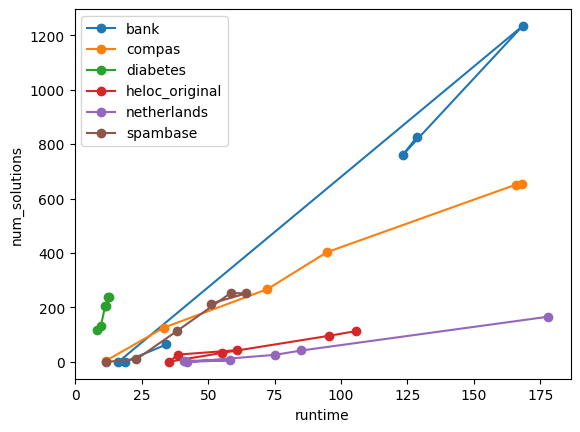

In [ ]:
with open(f"results/features.pkl", "rb") as f:
    results = pickle.load(f)
results = pd.DataFrame(results)

plot_two_var(results, "num_features", "runtime")
plot_two_var(results, "num_features", "num_solutions")
plot_two_var(results, "runtime", "num_solutions")

### Gap Tolerance

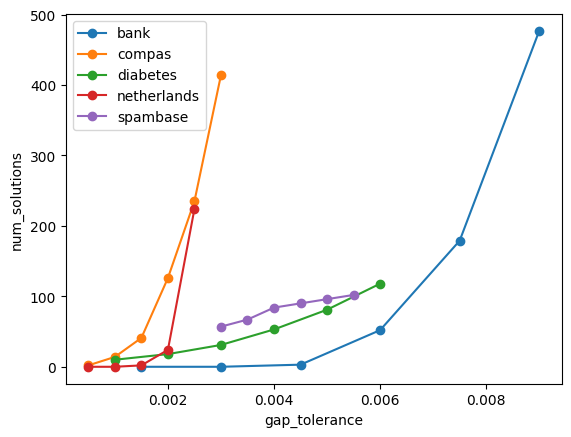

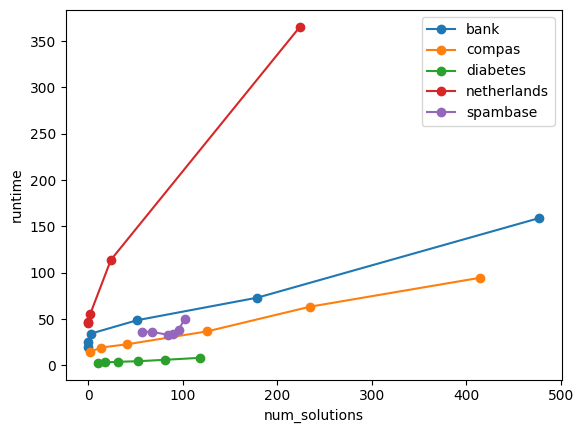

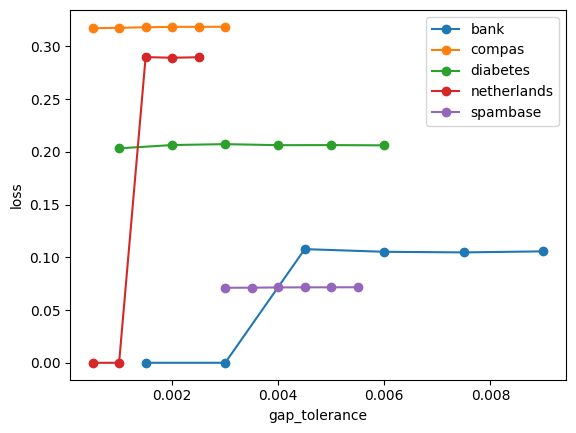

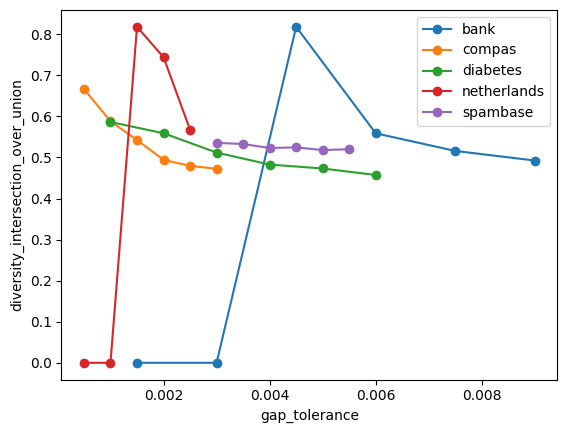

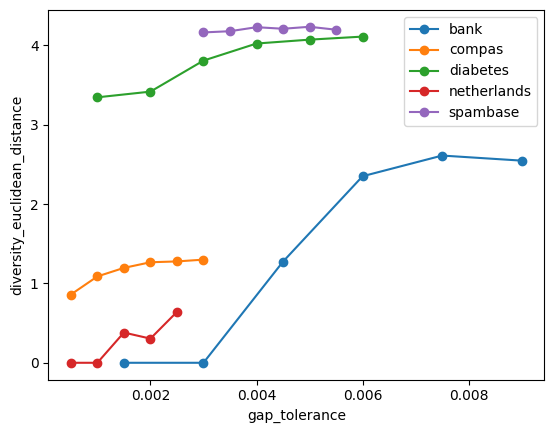

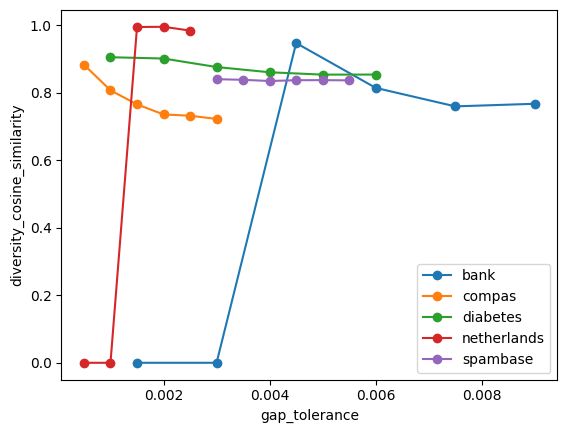

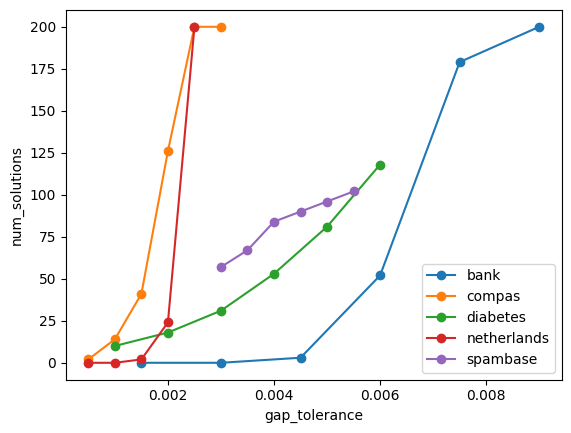

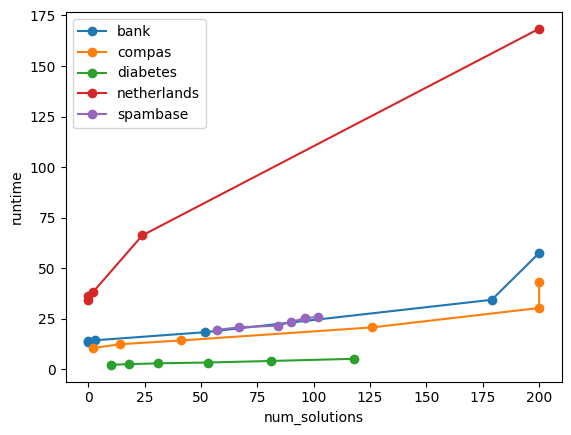

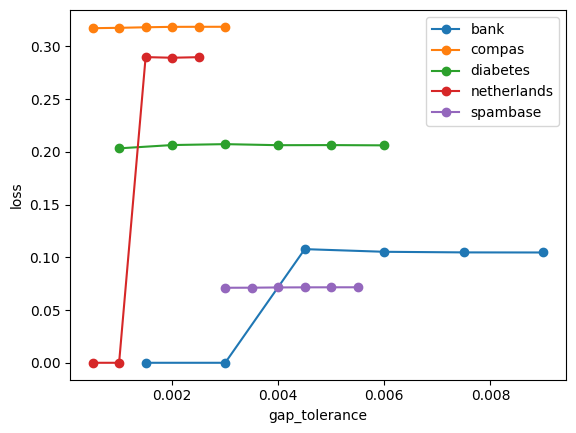

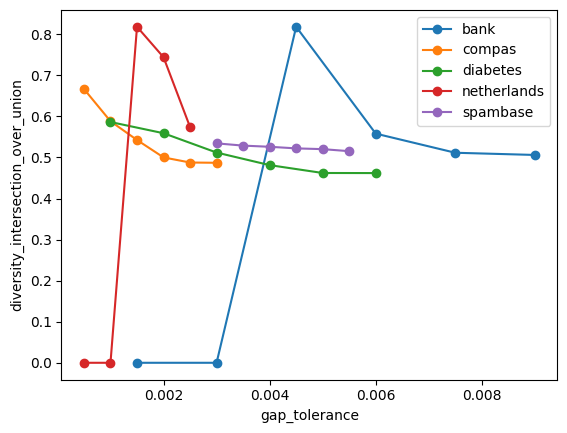

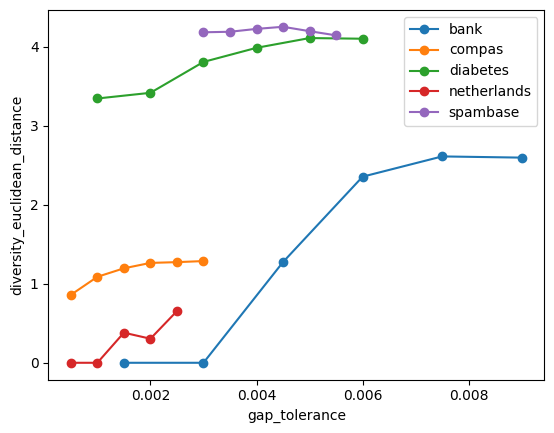

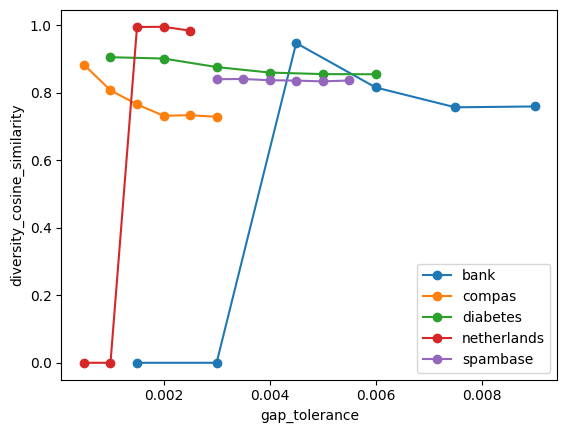

In [3]:
for file_name in ["tolerance", "tolerance_beam"]: # "tolerance_beam"
    with open(f"results/{file_name}.pkl", "rb") as f:
        results = pickle.load(f)
    results = pd.DataFrame(results)

    plot_two_var(results, "gap_tolerance", "num_solutions")
    plot_two_var(results, "num_solutions", "runtime")
    plot_two_var(results, "gap_tolerance", "loss")

    for diversity_fnc in [intersection_over_union, euclidean_distance, cosine_similarity]:
        col_name = f"diversity_{diversity_fnc.__name__}"
        results[col_name] = results["betas"].apply(lambda betas: average_pairwise_diversity(betas, diversity_fnc, 50))
        plot_two_var(results, "gap_tolerance", col_name)

### Swaps

In [6]:
def plot_swaps(file_name):
    with open(f"results/{file_name}.pkl", "rb") as f:
        results = pickle.load(f)
    results = pd.DataFrame(results)
    swaps = []
    for rep in [9, 11, 13, 10]:
        swaps.extend([1] * rep + [2] * rep + [3] * rep + [4] * rep + [5] * rep)
    results["swaps"] = swaps

    has_solutions_results = results[results['num_solutions'] > 0]
    min_gap_results = has_solutions_results.loc[
        has_solutions_results.groupby(['dataset', 'swaps'])['gap_tolerance'].idxmin()
    ]
    plot_two_var(min_gap_results, "swaps", "gap_tolerance")
    plot_two_var(min_gap_results, "swaps", "runtime")
    plot_two_var(min_gap_results, "swaps", "num_solutions")
    for diversity_fnc in [intersection_over_union, euclidean_distance, cosine_similarity]:
        col_name = f"diversity_{diversity_fnc.__name__}"
        min_gap_results[col_name] = min_gap_results["betas"].apply(lambda betas: average_pairwise_diversity(betas, diversity_fnc, 50))
        plot_two_var(min_gap_results, "swaps", col_name)

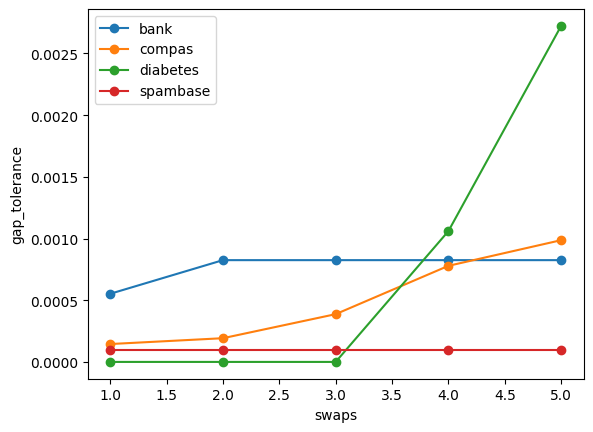

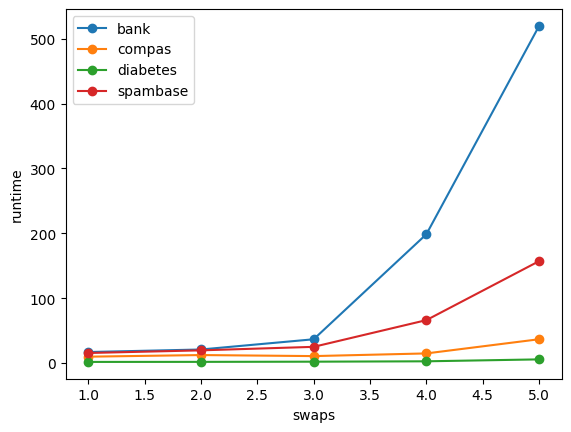

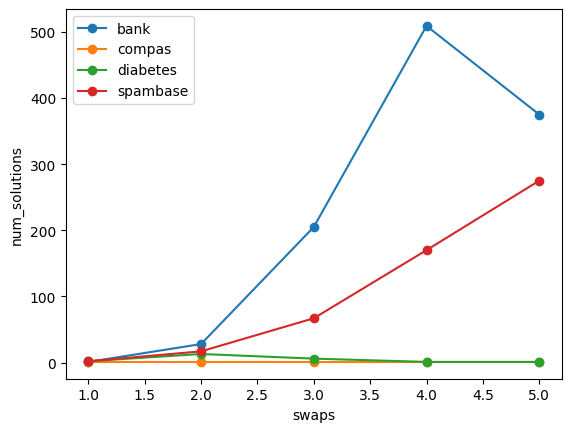

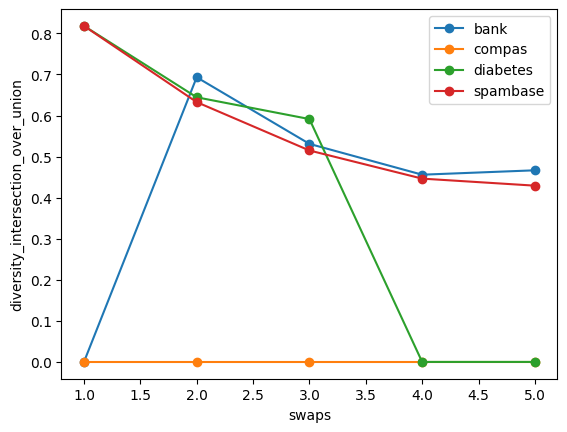

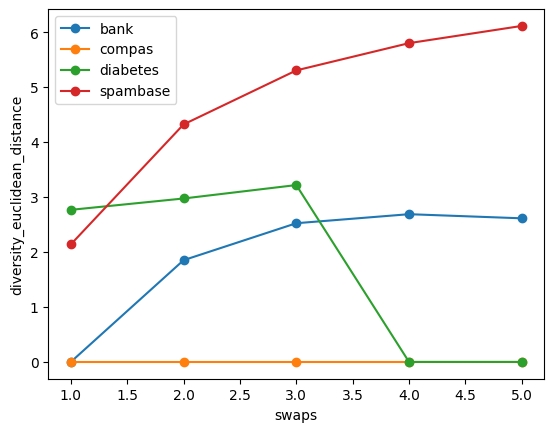

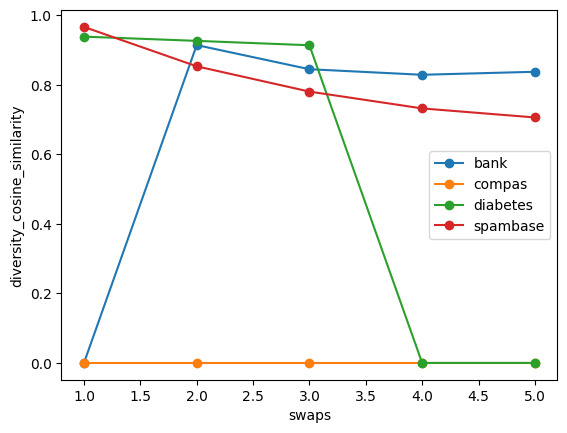

In [7]:
plot_swaps("swaps")

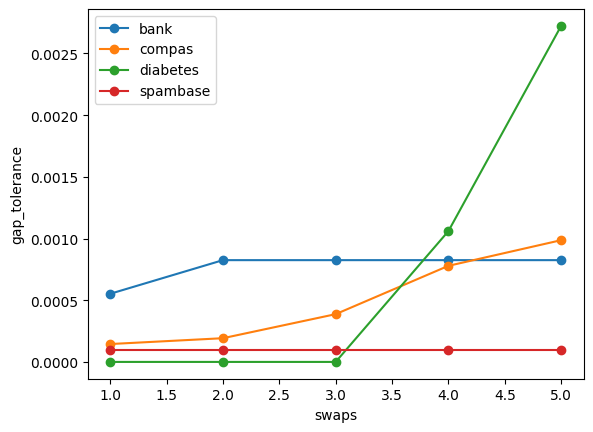

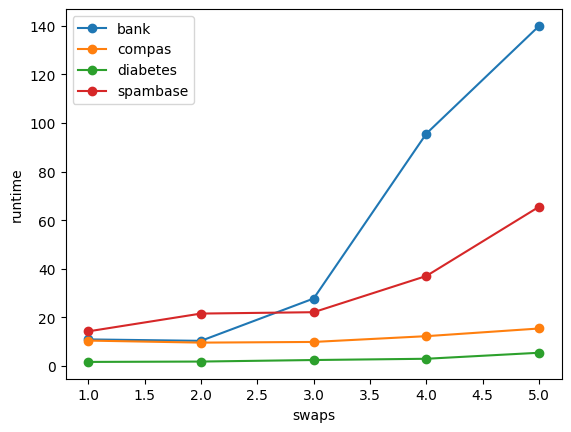

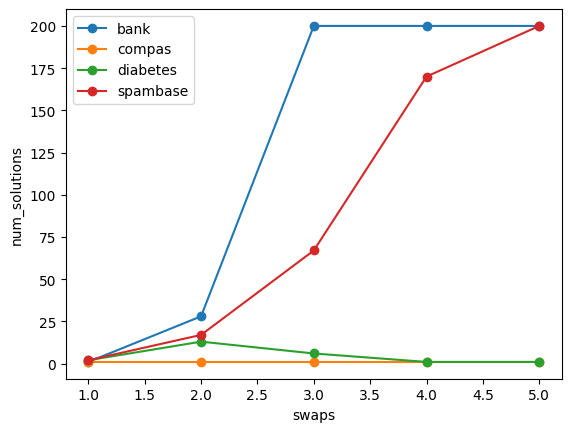

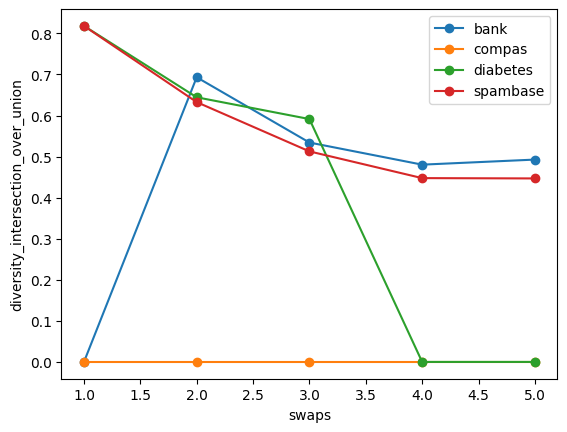

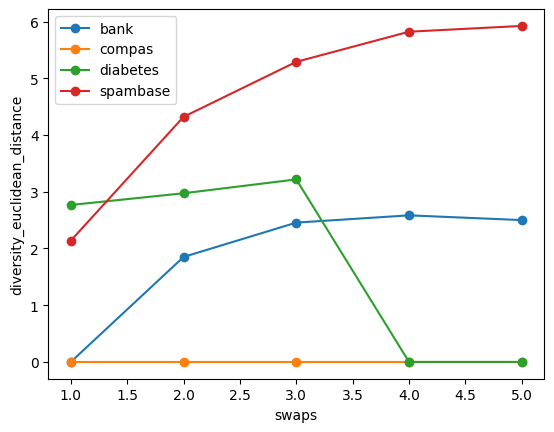

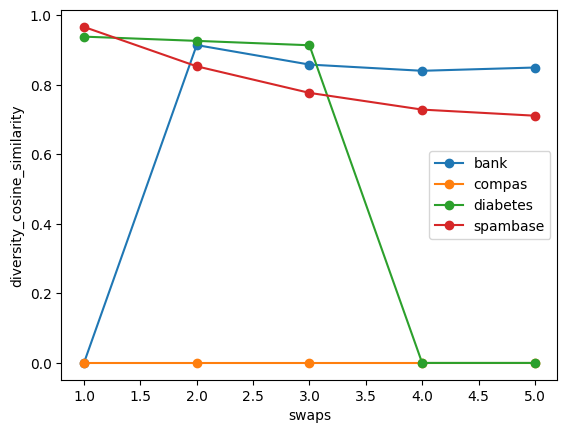

In [8]:
plot_swaps("swaps_beam")